# 01 Study Area and Data Inventory
**Project:** Pine Ridge Bison Habitat Suitability Analysis                
**Partner:** Oglala Lakota College (OLC)                           
**Territory:** Pine Ridge Reservation, Oglala Lakota Nation                    
**Author:** Lilly Jones, PhD, Daear Consulting, LLC                           

## Purpose
This notebook establishes the spatial foundation for all subsequent analysis:

1. Load and validate the Pine Ridge Reservation boundary
2. Create the template raster that defines the analysis grid
   (all BHSI layers align to this grid in notebooks 02–07)
3. Inventory available data coverage for each BHSI component
4. Produce a context map showing Pine Ridge within the broader
   Northern Great Plains landscape

## Why Start Here
All seven BHSI component rasters must share exactly the same coordinate
system, resolution, and extent before they can be combined in notebook 07.
The template raster created here is that common grid. Every subsequent
notebook reprojects its layer to match.

Starting with a careful boundary check also surfaces any geometric issues
in the Census TIGER data (slivers, invalid geometries) before they
propagate into the raster layers.

In [2]:
# Imports
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import contextily as ctx

from src.constants import (
    CRS_GEOGRAPHIC, CRS_PROJECTED,
    PINE_RIDGE_BBOX, PINE_RIDGE_LAT, PINE_RIDGE_LON,
    TARGET_RES_M, CACHE_DIR, OUTPUTS_DIR, FIGURES_DIR,
    BHSI_WEIGHTS,
)
from src.loaders import load_pine_ridge_boundary
from src.raster_utils import create_template_raster
from src.sovereignty import print_data_acknowledgment, generate_citations

warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline

def despine(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

print(f"Repo root    : {REPO_ROOT}")
print(f"Analysis CRS : {CRS_PROJECTED} (Albers Equal Area CONUS)")
print(f"Target res   : {TARGET_RES_M}m")

Repo root    : C:\Users\gekek\Documents\pine_ridge_bison_habitat\pine_ridge_bison_habitat
Analysis CRS : EPSG:5070 (Albers Equal Area CONUS)
Target res   : 30m


In [3]:
# Print data sovereignty statement at the top of every notebook
print_data_acknowledgment(source_keys=["census_aiannh"])


PINE RIDGE BISON HABITAT ANALYSIS DATA GOVERNANCE ACKNOWLEDGMENT
This analysis describes land within the Pine Ridge Reservation, home of
the Oglala Lakota Nation. Bison (Pte Oyate) hold deep cultural, spiritual,
and ecological significance for the Oglala Lakota people. This analysis
exists to support Tribal land stewardship, not to define it.

Results should be understood as one input into a land management
conversation, not as a determination of where bison belong.
That determination rests with the Oglala Lakota Nation.

GOVERNANCE FRAMEWORKS:

OCAP®  : The Oglala Lakota Nation has Ownership, Control, Access, and
  Possession of data describing their land and resources. Analysis results
  derived from public federal data about Pine Ridge still carry this
  obligation. Share results with OLC Cubedynamics and the relevant
  Oglala Lakota Nation land management offices before external distribution.
  Reference: https://fnigc.ca/ocap-training/

CARE   : Analysis must deliver Collective B

## Load and Validate Boundary

In [4]:
# Load Pine Ridge boundary from Census TIGER AIANNH
# First run: downloads ~30MB ZIP, caches. Subsequent runs: instant.

pine_ridge = load_pine_ridge_boundary()

print("PINE RIDGE RESERVATION BOUNDARY SUMMARY")
print(f"  Features     : {len(pine_ridge)}")
print(f"  CRS          : {pine_ridge.crs}")
print(f"  Area (km²)   : {pine_ridge['area_km2'].sum():,.0f} km²")
print(f"  Area (acres) : {pine_ridge['area_acres'].sum():,.0f} acres")
print(f"  Area (mi²)   : {pine_ridge['area_km2'].sum() / 2.59:,.0f} square miles")
print()

bounds = pine_ridge.total_bounds
print(f"  Bounding box (WGS84):")
print(f"    West  : {bounds[0]:.4f}°")
print(f"    South : {bounds[1]:.4f}°")
print(f"    East  : {bounds[2]:.4f}°")
print(f"    North : {bounds[3]:.4f}°")
print()

# Geometry validity check
invalid = (~pine_ridge.geometry.is_valid).sum()
print(f"  Invalid geometries : {invalid}")
if invalid > 0:
    print("  WARNING: Invalid geometries found: check shapely make_valid")
else:
    print("  All geometries valid")
print()
print("Note: Census boundaries are for statistical purposes only.")
print("They do not represent legal jurisdiction or Tribal self-definition.")

PINE RIDGE RESERVATION BOUNDARY SUMMARY
  Features     : 1
  CRS          : EPSG:4326
  Area (km²)   : 11,275 km²
  Area (acres) : 2,786,121 acres
  Area (mi²)   : 4,353 square miles

  Bounding box (WGS84):
    West  : -103.0010°
    South : 42.9874°
    East  : -101.2273°
    North : 43.7967°

  Invalid geometries : 0
  All geometries valid

Note: Census boundaries are for statistical purposes only.
They do not represent legal jurisdiction or Tribal self-definition.


## Create the Template Raster

In [5]:
# Create the 30m Albers template raster that all BHSI layers align to
# This defines: CRS, extent, pixel size, and boundary mask

template_path = CACHE_DIR / "template_30m_albers.tif"

template_path = create_template_raster(
    boundary_gdf = pine_ridge,
    output_path  = template_path,
    resolution_m = TARGET_RES_M,
    crs          = CRS_PROJECTED,
)

# Report template dimensions and area coverage
import rasterio
with rasterio.open(template_path) as src:
    tmpl_width  = src.width
    tmpl_height = src.height
    tmpl_data   = src.read(1)
    valid_pixels = (~np.isnan(tmpl_data)).sum()

pixel_area_acres = (TARGET_RES_M ** 2) / 4046.86
valid_area_acres = valid_pixels * pixel_area_acres

print(f"\nTemplate raster:")
print(f"  Dimensions  : {tmpl_width} × {tmpl_height} pixels")
print(f"  Total cells : {tmpl_width * tmpl_height:,}")
print(f"  Valid cells : {valid_pixels:,} (inside Pine Ridge boundary)")
print(f"  Valid area  : {valid_area_acres:,.0f} acres")
print(f"  Pixel size  : {TARGET_RES_M}m × {TARGET_RES_M}m = {pixel_area_acres:.2f} acres/pixel")
print(f"  Saved to    : {template_path.name}")

Template raster: 4946 × 2991 px @ 30m resolution
Extent: -567180E, 2234100N to -418800E, 2323830N (EPSG:5070)

Template raster:
  Dimensions  : 4946 × 2991 pixels
  Total cells : 14,793,486
  Valid cells : 12,527,845 (inside Pine Ridge boundary)
  Valid area  : 2,786,126 acres
  Pixel size  : 30m × 30m = 0.22 acres/pixel
  Saved to    : template_30m_albers.tif


## Data Coverage Inventory

In [6]:
# Pre-flight check: verify data coverage for each BHSI component
# before investing time in full downloads

print("BHSI COMPONENT DATA INVENTORY")

components = [
    {
        "name":    "Vegetation (NDVI and NLCD)",
        "weight":  BHSI_WEIGHTS["vegetation"],
        "sources": ["MODIS MOD13Q1 via ORNL DAAC", "NLCD 2021 via MRLC"],
        "notebook": "02",
    },
    {
        "name":    "Soils and Grazing Capacity",
        "weight":  BHSI_WEIGHTS["soils"],
        "sources": ["USDA gSSURGO via SoilDataAccess"],
        "notebook": "03",
    },
    {
        "name":    "Topography",
        "weight":  BHSI_WEIGHTS["topography"],
        "sources": ["USGS 3DEP 1/3 arc-second DEM via TNM"],
        "notebook": "04",
    },
    {
        "name":    "Water Access",
        "weight":  BHSI_WEIGHTS["water"],
        "sources": ["USGS NHDPlus HR streams and water bodies"],
        "notebook": "05",
    },
    {
        "name":    "Climate Stress",
        "weight":  BHSI_WEIGHTS["climate"],
        "sources": ["MACAv2-METDATA RCP 8.5 via OPeNDAP"],
        "notebook": "06",
    },
]

total_weight = sum(c["weight"] for c in components)

for c in components:
    bar = "█" * int(c["weight"] * 100)
    print(f"\n  NB {c['notebook']}: {c['name']}")
    print(f"    Weight  : {c['weight']*100:.0f}%  {bar}")
    for src in c["sources"]:
        print(f"    Source  : {src}")

print(f"\n  Total weight: {total_weight:.2f} " if abs(total_weight - 1.0) < 0.01
      else f"\n  WARNING: weights sum to {total_weight:.2f}, not 1.0")

BHSI COMPONENT DATA INVENTORY

  NB 02: Vegetation (NDVI and NLCD)
    Weight  : 30%  ██████████████████████████████
    Source  : MODIS MOD13Q1 via ORNL DAAC
    Source  : NLCD 2021 via MRLC

  NB 03: Soils and Grazing Capacity
    Weight  : 20%  ████████████████████
    Source  : USDA gSSURGO via SoilDataAccess

  NB 04: Topography
    Weight  : 15%  ███████████████
    Source  : USGS 3DEP 1/3 arc-second DEM via TNM

  NB 05: Water Access
    Weight  : 25%  █████████████████████████
    Source  : USGS NHDPlus HR streams and water bodies

  NB 06: Climate Stress
    Weight  : 10%  ██████████
    Source  : MACAv2-METDATA RCP 8.5 via OPeNDAP

  Total weight: 1.00 


## Context Map

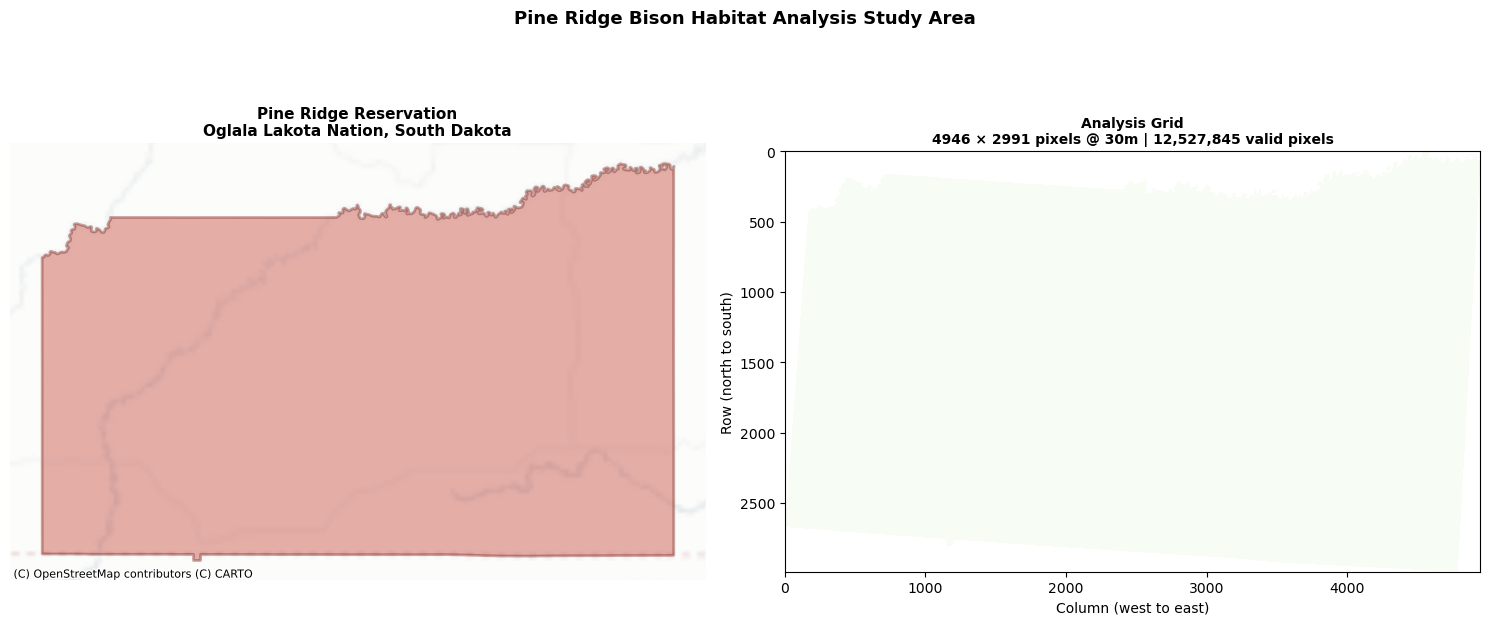

Figure saved: figures/01_study_area.png


In [7]:
# Overview map: Pine Ridge in regional context

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Left: regional context
ax = axes[0]
pine_ridge.to_crs(3857).plot(
    ax=ax, facecolor="#C0392B", alpha=0.4,
    edgecolor="#7B241C", linewidth=2, zorder=3,
)
try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron,
                   zoom=7, alpha=0.6)
except Exception:
    pass
ax.set_axis_off()
ax.set_title(
    "Pine Ridge Reservation\nOglala Lakota Nation, South Dakota",
    fontsize=11, fontweight="bold",
)

# Right: template raster boundary mask
ax = axes[1]
ax.imshow(
    tmpl_data,
    cmap="Greens", origin="upper",
    interpolation="none",
)
ax.set_title(
    f"Analysis Grid\n"
    f"{tmpl_width} × {tmpl_height} pixels @ {TARGET_RES_M}m | "
    f"{valid_pixels:,} valid pixels",
    fontsize=10, fontweight="bold",
)
ax.set_xlabel("Column (west to east)")
ax.set_ylabel("Row (north to south)")

plt.suptitle(
    "Pine Ridge Bison Habitat Analysis Study Area",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURES_DIR/"01_study_area.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved: figures/01_study_area.png")

## Export for Subsequent Notebooks

In [8]:
# Save boundary to outputs/ for use by notebooks 02–07
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

boundary_out = OUTPUTS_DIR/"pine_ridge_boundary.geojson"
pine_ridge.to_file(boundary_out, driver="GeoJSON")
print(f"Boundary saved    : outputs/pine_ridge_boundary.geojson")
print(f"Template raster   : data/cache/template_30m_albers.tif")
print()
print("Both files are used by all subsequent notebooks.")
print("Run this notebook first before any others in the series.")

Boundary saved    : outputs/pine_ridge_boundary.geojson
Template raster   : data/cache/template_30m_albers.tif

Both files are used by all subsequent notebooks.
Run this notebook first before any others in the series.


In [9]:
print(generate_citations(["census_aiannh"]))

DATA CITATIONS

US Census Bureau TIGER/Line AIANNH Boundaries
  https://www.census.gov/cgi-bin/geo/shapefiles/index.php
  Steward: US Census Bureau | License: Public domain

Governance: OCAP® | CARE | FAIR | IEEE 2890-2025
  OCAP: https://fnigc.ca/ocap-training/
  CARE: https://www.gida-global.org/care
  FAIR: https://www.go-fair.org/fair-principles/
  IEEE_2890: https://standards.ieee.org/ieee/2890/10318/
